# Example 2: Non-Isothermal Plug-Flow Tubular Reactor

This example is adapted from Jens Hagen, Chemiereaktoren: Grundlagen, Auslegung und Simulation, Wiley, 2017, doi: 10.1002/9783527806614, Bsp. 8.5

This notebook implements the numerical solution of the one-dimensional steady-state material and energy balances derived in Example 2 for the exothermic hydrolysis of ethylene oxide (EO) with water to ethylene glycol (EG).

Water is present in large excess, so the reaction is treated as pseudo-first-order in EO. The article discusses the adiabatic PFTR and the polytropic PFTR with $T_\mathrm{wall}=440\,\mathrm{K}$; the notebook also retains the neighboring wall-temperature variants $430\,\mathrm{K}$ and $450\,\mathrm{K}$ for comparison.

**Goals**
1. Solve the coupled initial-value problem for $c_\mathrm{EO}(z)$ and $T(z)$.
2. Compare the adiabatic profile with polytropic profiles at different wall temperatures.
3. Provide pgfplots-compatible data blocks for the article figure.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


## Parameters

All parameters are collected in a single dictionary $\texttt{params}$, so later variations require changing only one cell. The default set mirrors the values stated in Example 2.

The kinetic expression is written as:

\begin{equation}
k(T)=5.01\cdot \exp^6\,10^{-72500/R\,T}\;\mathrm{s^{-1}}.
\end{equation}

| Quantity | Symbol | Default |
| --- | --- | --- |
| Fluid velocity | $u$ | $1\,\mathrm{m\,s^{-1}}$ |
| EO inlet concentration | $c_{\mathrm{EO},0}$ | $2.27\,\mathrm{mol\,L^{-1}}$ |
| Inlet temperature | $T_0$ | $423\,\mathrm{K}$ |
| Reaction enthalpy | $\Delta_\mathrm{R}H$ | $-92.2\,\mathrm{kJ\,mol^{-1}}$ |
| Density | $\rho$ | $1000\,\mathrm{kg\,m^{-3}}$ |
| Heat capacity | $c_p$ | $4.19\,\mathrm{kJ\,kg^{-1}\,K^{-1}}$ |
| Tube diameter | $d_\mathrm{react}$ | $0.03\,\mathrm{m}$ |
| Wall heat-transfer coefficient | $h_\mathrm{wall}$ | $0.5\,\mathrm{kJ\,s^{-1}\,m^{-2}\,K^{-1}}$ |
| Wall temperatures | $T_\mathrm{wall}$ | $430,\,440,\,450\,\mathrm{K}$ |
| Reactor length | $L$ | $300\,\mathrm{m}$ |


In [18]:
params = {
    "u": 1.0,                         # fluid velocity, m/s
    "c_EO_in": 2.27e3,                # EO inlet concentration, mol/m^3
    "T_in": 423.0,                    # inlet temperature, K
    "delta_R_H": -92.2,               # reaction enthalpy, kJ/mol
    "rho": 1000.0,                    # density, kg/m^3
    "cp": 4.19,                       # heat capacity, kJ/(kg K)
    "k0": 5.01e6,                     # pre-exponential factor, 1/s
    "arrhenius_exponent": 72500/8.3145,     # activation energy divided by ideal gas constant, K
    "d_reactor": 0.03,                # tube diameter, m
    "h_wall": 0.5,                    # wall heat-transfer coefficient, kJ/(s m^2 K)
    "T_wall": 440.0,                  # article reference wall temperature, K
    "T_wall_values": [430.0, 440.0, 450.0],  # wall-temperature variants, K
    "L": 300.0,                       # reactor length, m
}
params["a_wall"] = 4.0 / params["d_reactor"]  # area-to-volume ratio for a cylinder, 1/m

z_eval = np.linspace(0.0, params["L"], 301)

cases = {"adiabatic": {"T_wall": None}}
cases.update({
    f"T_wall = {T_wall:.0f} K": {"T_wall": T_wall}
    for T_wall in params["T_wall_values"]
})


## Reaction rate

The reaction rate is pseudo-first-order in ethylene oxide,

\begin{equation}
r = k(T)c_\mathrm{EO}.
\end{equation}

The concentration is kept in $\mathrm{mol\,m^{-3}}$, so $r$ is obtained in $\mathrm{mol\,m^{-3}\,s^{-1}}$.


In [19]:
def k_T(T, p):
    """Pseudo-first-order rate constant in 1/s."""
    return p["k0"] * np.exp (-p["arrhenius_exponent"] / np.asarray(T))


def reaction_rate(c_EO, T, p):
    """Reaction rate r = k(T) c_EO in mol/(m^3 s)."""
    return k_T(T, p) * np.maximum(c_EO, 0.0)


## PFTR balances

For steady state, constant velocity and plug flow, the material balance becomes

\begin{equation}
\frac{\mathrm{d}c_\mathrm{EO}}{\mathrm{d}z}=-\frac{r}{u}.
\end{equation}

The energy balance is implemented as

\begin{equation}
\frac{\mathrm{d}T}{\mathrm{d}z}=\frac{-\Delta_\mathrm{R}H\,r+h_\mathrm{wall}a_\mathrm{wall}\left(T_\mathrm{wall}-T\right)}{\rho c_p u}.
\end{equation}

For the adiabatic case the wall term is set to zero.


In [20]:
def pftr_rhs(z, y, p, T_wall=None):
    """Right-hand side of the article PFTR model (order: c_EO, T)."""
    c_EO, T = y
    r = reaction_rate(c_EO, T, p)

    dc_EO_dz = -r / p["u"]
    q_reaction = -p["delta_R_H"] * r
    q_wall = 0.0 if T_wall is None else p["h_wall"] * p["a_wall"] * (T_wall - T)
    dT_dz = (q_reaction + q_wall) / (p["rho"] * p["cp"] * p["u"])

    return [dc_EO_dz, dT_dz]


## Numerical integration

The inlet conditions are

\begin{equation}
c_\mathrm{EO}(0)=2.27\,\mathrm{mol\,L^{-1}},\qquad T(0)=423\,\mathrm{K}.
\end{equation}

Both cases are integrated over $0\leq z\leq300\,\mathrm{m}$ with the same axial grid used for the article figure.


In [21]:
def solve_case(label, case, p):
    """Solve one PFTR case and return profiles in article units."""
    sol = solve_ivp(
        lambda z, y: pftr_rhs(z, y, p, case["T_wall"]),
        (z_eval[0], z_eval[-1]),
        [p["c_EO_in"], p["T_in"]],
        t_eval=z_eval,
        method="RK45",
        rtol=1e-9,
        atol=[1e-7, 1e-9],
    )
    if not sol.success:
        raise RuntimeError(f"Integration failed for {label}: {sol.message}")
    return {
        "z_m": sol.t,
        "c_EO_mol_L": sol.y[0] / 1000.0,
        "T_K": sol.y[1],
        "conversion": 1.0 - sol.y[0] / p["c_EO_in"],
    }


results = {label: solve_case(label, case, params) for label, case in cases.items()}

print(f"{'case':<16} {'T_max / K':>10} {'z(T_max) / m':>13} {'T(L) / K':>10} {'X_EO(L)':>10}")
for label, data in results.items():
    idx_max = np.argmax(data["T_K"])
    print(
        f"{label:<16} "
        f"{data['T_K'][idx_max]:>10.2f} "
        f"{data['z_m'][idx_max]:>13.1f} "
        f"{data['T_K'][-1]:>10.2f} "
        f"{data['conversion'][-1]:>10.4f}"
    )


case              T_max / K  z(T_max) / m   T(L) / K    X_EO(L)
adiabatic            472.95         300.0     472.95     1.0000
T_wall = 430 K       445.27         101.0     432.67     0.9698
T_wall = 440 K       456.19          97.0     441.66     0.9943
T_wall = 450 K       466.15          90.0     451.04     0.9994


## Axial profiles

The following plot reproduces the qualitative comparison in the article and keeps the additional wall-temperature variants. For wall temperatures above the inlet temperature the polytropic reactor first heats up, then cools after passing through the hot spot. The adiabatic reactor approaches its maximum temperature at the outlet.


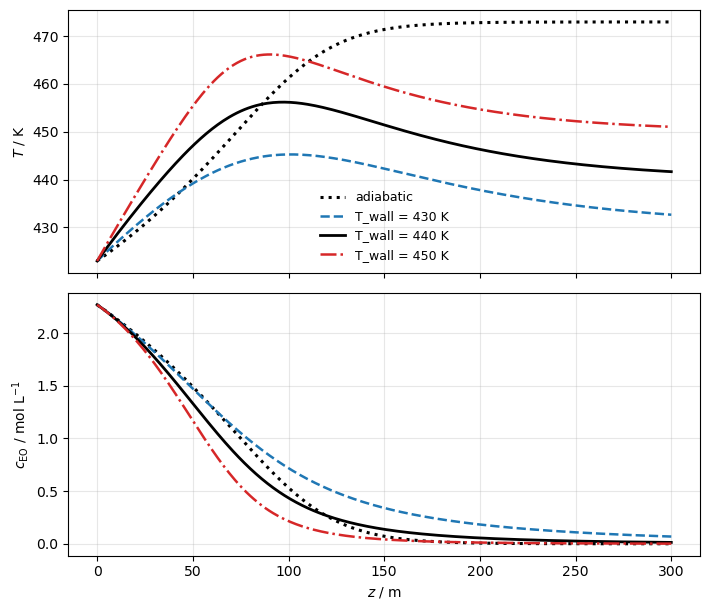

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.2), sharex=True)

plot_styles = {
    "adiabatic": {"color": "black", "linestyle": ":", "linewidth": 2.2},
    "T_wall = 430 K": {"color": "tab:blue", "linestyle": "--", "linewidth": 1.8},
    "T_wall = 440 K": {"color": "black", "linestyle": "-", "linewidth": 2.0},
    "T_wall = 450 K": {"color": "tab:red", "linestyle": "-.", "linewidth": 1.8},
}

for label, data in results.items():
    axes[0].plot(data["z_m"], data["T_K"], label=label, **plot_styles[label])
axes[0].set_ylabel(r"$T$ / K")
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=False, fontsize=9)

for label, data in results.items():
    axes[1].plot(data["z_m"], data["c_EO_mol_L"], label=label, **plot_styles[label])
axes[1].set_xlabel(r"$z$ / m")
axes[1].set_ylabel(r"$c_{\mathrm{EO}}$ / mol L$^{-1}$")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


## Verification

The checks below verify monotonic EO consumption, finite temperature profiles and the expected hot-spot behavior for the polytropic case.


In [23]:
for label, data in results.items():
    dc = np.diff(data["c_EO_mol_L"])
    assert np.all(dc <= 1e-10), f"EO concentration is not monotone for {label}."
    assert np.all(np.isfinite(data["T_K"])), f"Temperature profile contains non-finite values for {label}."

polytropic_labels = [label for label in results if label != "adiabatic"]
hot_spots = {}
for label in polytropic_labels:
    idx_max = np.argmax(results[label]["T_K"])
    assert 0 < idx_max < len(z_eval) - 1
    hot_spots[label] = idx_max
assert np.argmax(results["adiabatic"]["T_K"]) == len(z_eval) - 1

print("verification ok")
for label, idx_max in hot_spots.items():
    print(f"{label}: z(T_max) = {results[label]['z_m'][idx_max]:.1f} m, "
          f"T_max = {results[label]['T_K'][idx_max]:.2f} K")


verification ok
T_wall = 430 K: z(T_max) = 101.0 m, T_max = 445.27 K
T_wall = 440 K: z(T_max) = 97.0 m, T_max = 456.19 K
T_wall = 450 K: z(T_max) = 90.0 m, T_max = 466.15 K


## pgfplots data

The following helper reproduces the table format used in figures/ex2_fig.tex. Values are sampled every $10\,\mathrm{m}$, matching the article figure. The table dictionary includes all wall-temperature variants; the article figure currently uses the adiabatic case and $T_\mathrm{wall}=440\,\mathrm{K}$.


In [24]:
z_latex = np.arange(0.0, params["L"] + 0.1, 10.0)


def format_pgf_table(label, quantity, column_name):
    data = results[label]
    values = np.interp(z_latex, data["z_m"], data[quantity])
    lines = [f"z {column_name}"]
    for z_i, value_i in zip(z_latex, values):
        lines.append(f"{z_i:.0f} {value_i:.6g}")
    return "\n".join(lines)


pgf_tables = {
    "T_adiabatic": format_pgf_table("adiabatic", "T_K", "T_adiabatic"),
    "c_adiabatic": format_pgf_table("adiabatic", "c_EO_mol_L", "c_adiabatic"),
}
for T_wall in params["T_wall_values"]:
    label = f"T_wall = {T_wall:.0f} K"
    suffix = f"Tw{T_wall:.0f}"
    pgf_tables[f"T_{suffix}"] = format_pgf_table(label, "T_K", f"T_{suffix}")
    pgf_tables[f"c_{suffix}"] = format_pgf_table(label, "c_EO_mol_L", f"c_{suffix}")

for name, table in pgf_tables.items():
    print(f"% {name}")
    print(table)
    print()


% T_adiabatic
z T_adiabatic
0 423
10 425.907
20 429.06
30 432.476
40 436.168
50 440.132
60 444.335
70 448.705
80 453.109
90 457.359
100 461.234
110 464.537
120 467.157
130 469.101
140 470.462
150 471.373
160 471.964
170 472.339
180 472.574
190 472.719
200 472.809
210 472.864
220 472.898
230 472.918
240 472.931
250 472.939
260 472.943
270 472.946
280 472.948
290 472.949
300 472.95

% c_adiabatic
z c_adiabatic
0 2.27
10 2.13789
20 1.99462
30 1.83935
40 1.67156
50 1.49144
60 1.30042
70 1.10186
80 0.901708
90 0.708553
100 0.53246
110 0.382375
120 0.263279
130 0.174956
140 0.113117
150 0.0717061
160 0.0448482
170 0.027804
180 0.0171405
190 0.0105294
200 0.00645397
210 0.0039506
220 0.00241622
230 0.00147702
240 0.000902612
250 0.000551484
260 0.000336909
270 0.000205808
280 0.000125717
290 7.67913e-05
300 4.69055e-05

% T_Tw430
z T_Tw430
0 423
10 426.784
20 430.325
30 433.602
40 436.575
50 439.187
60 441.376
70 443.089
80 444.297
90 445.008
100 445.263
110 445.128
120 444.686
130 444.019
14